# Notebook 00 — Exploratory Data Analysis

## Requires
- `data/raw/training_setA/` and `data/raw/training_setB/` (raw .psv patient files)

## Produces
- `results/figures/missingness_by_feature.png`
- `results/figures/missingness_heatmap.png`
- `results/figures/class_distribution.png`
- `results/figures/icu_stay_distribution.png`
- `results/figures/time_to_sepsis.png`
- `results/figures/feature_distributions.png`
- `results/figures/vital_trajectories_sepsis_vs_not.png`
- `results/figures/feature_correlation_matrix.png`
- `results/metrics/integrity_report.txt`

## Run Order
Run this **FIRST** — before any preprocessing or modelling.

In [1]:
import sys
from pathlib import Path

# Locate project root — works whether kernel CWD is project root or notebooks/
_here = Path.cwd()
if (_here / 'src').exists():
    _root = _here            # already at project root
elif (_here.parent / 'src').exists():
    _root = _here.parent     # one level up (e.g. running from notebooks/)
else:
    _root = _here            # fallback (Colab: setup cell above should handle this)

if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    RANDOM_SEED, DATA_DIR, FIGURES_DIR, METRICS_DIR,
    ALL_FEATURES, VITAL_SIGNS, LAB_VALUES, DEMOGRAPHICS
)

np.random.seed(RANDOM_SEED)
Path(_root / FIGURES_DIR).mkdir(parents=True, exist_ok=True)
Path(_root / METRICS_DIR).mkdir(parents=True, exist_ok=True)

print(f'Project root : {_root}')
print('Imports OK')

Project root : /Users/user/Desktop/ML_Final Project/Sepsis_ML_Prediction
Imports OK


## 1. Load All Patients

Loading all `.psv` files from Set A and Set B into a single DataFrame, assigning a `patient_id` column during ingestion. With 40,336 files this takes a couple of minutes.

In [3]:
from tqdm import tqdm

SET_A_DIR = _root / 'data' / 'raw' / 'training_setA'
SET_B_DIR = _root / 'data' / 'raw' / 'training_setB'

def load_all_patients():
    """Load all .psv files into one DataFrame with a patient_id column."""
    all_files = sorted(SET_A_DIR.glob('*.psv')) + sorted(SET_B_DIR.glob('*.psv'))

    if not all_files:
        raise FileNotFoundError(
            f"No .psv files found in:\n  {SET_A_DIR}\n  {SET_B_DIR}\n\n"
            "Locally: run 'python3 src/download_data.py' from the project root."
        )

    dfs = []
    for f in tqdm(all_files, desc='Loading patients'):
        d = pd.read_csv(f, sep='|')
        d['patient_id'] = f.stem
        dfs.append(d)
    return pd.concat(dfs, ignore_index=True)

df = load_all_patients()
print(f'Loaded {df["patient_id"].nunique():,} patients  |  {len(df):,} total rows')

Loading patients: 100%|██████████| 40336/40336 [02:04<00:00, 322.97it/s]


Loaded 40,336 patients  |  1,552,210 total rows


## 2. Missingness Analysis

### 2a — Per-Feature Missingness Rates

Lab values are collected on clinical demand rather than a fixed schedule, so I expect vitals to have relatively low missingness and rare labs — lactate, troponin — to be missing in over 90% of rows. The actual rates determine whether this asymmetry is strong enough to motivate Strategy B.

Feature Missingness (%):
Bilirubin_direct    99.807371
Fibrinogen          99.340167
TroponinI           99.047745
Bilirubin_total     98.509158
Alkalinephos        98.393194
AST                 98.377604
Lactate             97.329872
PTT                 97.055875
SaO2                96.549372
EtCO2               96.286843
Phosphate           95.986303
HCO3                95.810618
Chloride            95.460279
BaseExcess          94.579020
PaCO2               94.440121
Calcium             94.116067
Platelets           94.059502
Creatinine          93.904433
Magnesium           93.689578
WBC                 93.593199
BUN                 93.134434
pH                  93.069688
Hgb                 92.617558
FiO2                91.665754
Hct                 91.145979
Potassium           90.689082
Glucose             82.894325
Temp                66.162697
Unit2               39.425078
Unit1               39.425078
DBP                 31.345887
Resp                15.354559
SBP            

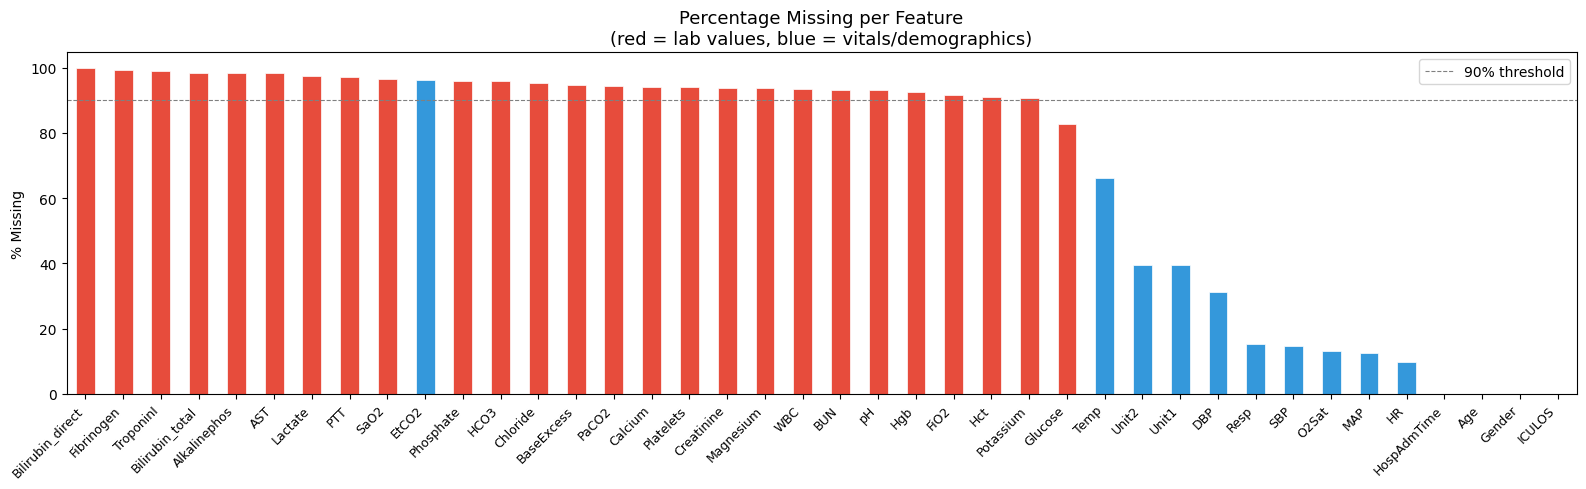

Saved → results/figures/missingness_by_feature.png


In [4]:
missing_pct = df[ALL_FEATURES].isna().mean().sort_values(ascending=False) * 100

print("Feature Missingness (%):")
print(missing_pct.to_string())

fig, ax = plt.subplots(figsize=(16, 5))
colors = ['#e74c3c' if f in LAB_VALUES else '#3498db' for f in missing_pct.index]
missing_pct.plot(kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Percentage Missing per Feature\n(red = lab values, blue = vitals/demographics)', fontsize=13)
ax.set_ylabel('% Missing')
ax.set_xlabel('')
ax.axhline(90, color='grey', linestyle='--', linewidth=0.8, label='90% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(_root / FIGURES_DIR / 'missingness_by_feature.png', dpi=150)
plt.show()
print("Saved → results/figures/missingness_by_feature.png")

### 2b — Missingness Heatmap

Sampling 200 patients to visualise which timesteps actually contain lab measurements. Each row is a patient, each column an ICU hour — this captures the temporal structure of missing data more clearly than summary statistics alone.

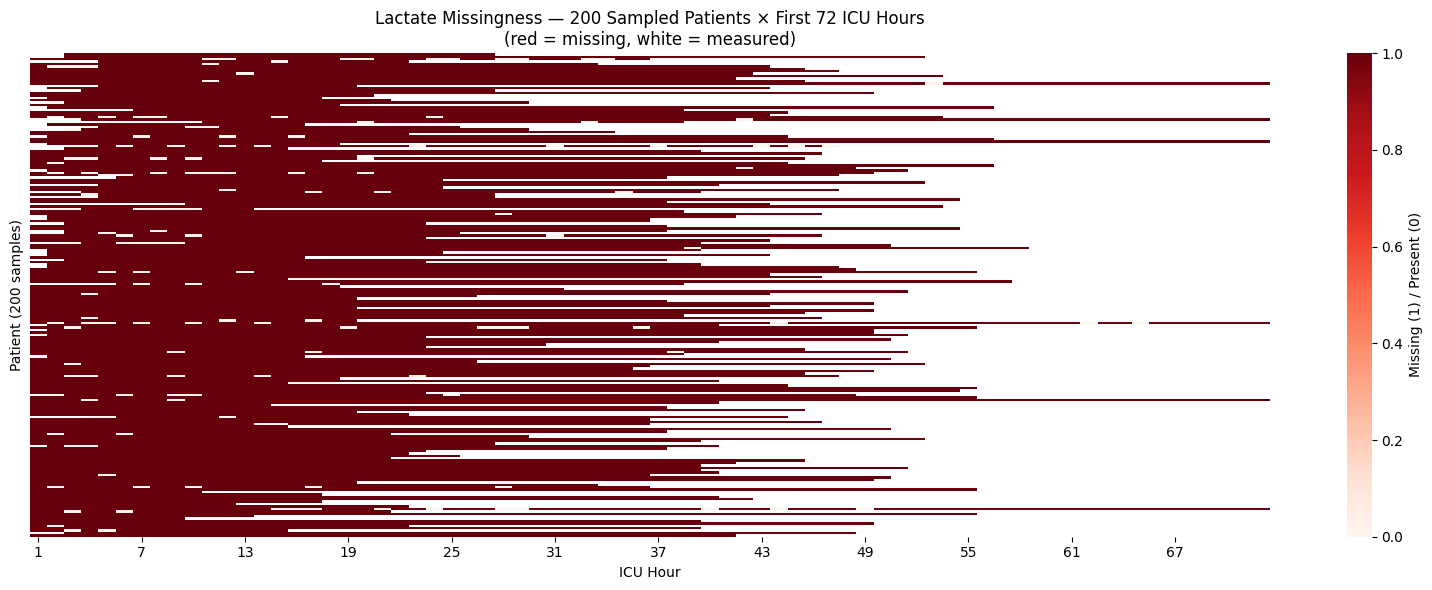

Saved → results/figures/missingness_heatmap.png


In [5]:
np.random.seed(RANDOM_SEED)
sample_ids = np.random.choice(df['patient_id'].unique(), size=200, replace=False)
sample_df  = df[df['patient_id'].isin(sample_ids)].copy()

# Focus on Lactate — highest clinical relevance, highest missingness
pivot = sample_df.pivot_table(
    index='patient_id', columns='ICULOS',
    values='Lactate', aggfunc=lambda x: float(x.isna().all())
)
# Trim to first 72h (our MAX_SEQ_LEN)
pivot = pivot[[c for c in pivot.columns if c <= 72]]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot, cmap='Reds', cbar_kws={'label': 'Missing (1) / Present (0)'},
            ax=ax, xticklabels=6, yticklabels=False)
ax.set_title('Lactate Missingness — 200 Sampled Patients × First 72 ICU Hours\n'
             '(red = missing, white = measured)', fontsize=12)
ax.set_xlabel('ICU Hour')
ax.set_ylabel('Patient (200 samples)')
plt.tight_layout()
plt.savefig(_root / FIGURES_DIR / 'missingness_heatmap.png', dpi=150)
plt.show()
print("Saved → results/figures/missingness_heatmap.png")

### 2c — Testing Whether Missingness is Informative

Comparing per-feature missingness rates between sepsis and non-sepsis patients. If the rates differ consistently, the missingness pattern is clinically driven rather than random — which would justify Strategy B's approach of encoding absent values as explicit binary indicators.

In [6]:
# Patient-level labels: 1 if SepsisLabel ever = 1, else 0
patient_labels = df.groupby('patient_id')['SepsisLabel'].max().reset_index()
patient_labels.columns = ['patient_id', 'is_sepsis']

sepsis_ids     = set(patient_labels[patient_labels['is_sepsis'] == 1]['patient_id'])
non_sepsis_ids = set(patient_labels[patient_labels['is_sepsis'] == 0]['patient_id'])

df_sep     = df[df['patient_id'].isin(sepsis_ids)]
df_non_sep = df[df['patient_id'].isin(non_sepsis_ids)]

mnar_rows = []
for feat in LAB_VALUES:
    sep_miss     = df_sep[feat].isna().mean() * 100
    non_sep_miss = df_non_sep[feat].isna().mean() * 100
    diff         = sep_miss - non_sep_miss
    mnar_rows.append({
        'feature':              feat,
        'sepsis_missing_%':     round(sep_miss, 1),
        'non_sepsis_missing_%': round(non_sep_miss, 1),
        'difference_%':         round(diff, 1),
    })

mnar_df = (pd.DataFrame(mnar_rows)
             .sort_values('difference_%', key=abs, ascending=False)
             .reset_index(drop=True))

print(f"Sepsis patients    : {len(sepsis_ids):,}")
print(f"Non-sepsis patients: {len(non_sepsis_ids):,}")
print(f"\nMNAR Comparison (sorted by |difference|):")
print(mnar_df.to_string(index=False))

mnar_df.to_csv(_root / METRICS_DIR / 'mnar_comparison.csv', index=False)
print(f"\nSaved → results/metrics/mnar_comparison.csv")

Sepsis patients    : 2,932
Non-sepsis patients: 37,404

MNAR Comparison (sorted by |difference|):
         feature  sepsis_missing_%  non_sepsis_missing_%  difference_%
            FiO2              83.3                  92.7          -9.5
              pH              88.9                  93.6          -4.7
           PaCO2              90.8                  94.9          -4.1
      BaseExcess              91.1                  95.0          -3.9
         Lactate              94.6                  97.7          -3.0
       Potassium              88.4                  91.0          -2.5
        Chloride              93.6                  95.7          -2.1
       Magnesium              92.0                  93.9          -1.9
            HCO3              94.2                  96.0          -1.8
         Calcium              92.6                  94.3          -1.7
       Phosphate              94.6                  96.2          -1.6
            SaO2              95.1                

### 2d — Missingness Pattern: Findings

**Lab missingness is Missing Not At Random (MNAR).**

Across all 26 lab values, sepsis patients have consistently *lower* missingness rates than non-sepsis patients. The largest differences are in FiO2 (−9.5%), pH (−4.7%), PaCO2 (−4.1%), and Lactate (−3.0%). This is consistent with clinical practice: arterial blood gas panels and lactate draws are ordered precisely when a patient shows signs of deterioration or suspected sepsis. A measurement being present is itself a signal of clinical concern.

Strategy A (median imputation) discards this signal entirely. Strategy B (forward-fill + missingness indicator columns) preserves it with binary flags encoding when each lab was measured. If Strategy B outperforms Strategy A in the 2×2 experiment, this MNAR finding provides the mechanistic justification.

## 3. Class Distribution and Label Analysis

### 3a — Patient-Level Class Distribution

Checking sepsis prevalence at patient level. With such a heavily skewed dataset, accuracy is a misleading metric — a model predicting no sepsis for every patient would still score above 93%. AUPRC is the appropriate primary metric here.

Total patients       : 40,336
Sepsis patients      : 2,932  (7.3%)
Non-sepsis patients  : 37,404  (92.7%)
Imbalance ratio      : 1 : 13


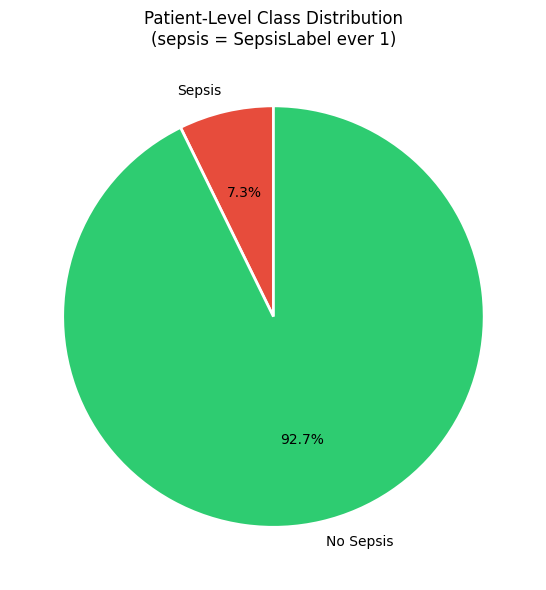

Saved → results/figures/class_distribution.png


In [7]:
patient_labels = df.groupby('patient_id')['SepsisLabel'].max()
n_sepsis  = int(patient_labels.sum())
n_total   = len(patient_labels)
n_healthy = n_total - n_sepsis

print(f"Total patients       : {n_total:,}")
print(f"Sepsis patients      : {n_sepsis:,}  ({100*n_sepsis/n_total:.1f}%)")
print(f"Non-sepsis patients  : {n_healthy:,}  ({100*n_healthy/n_total:.1f}%)")
print(f"Imbalance ratio      : 1 : {n_healthy/n_sepsis:.0f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [n_sepsis, n_healthy],
    labels=['Sepsis', 'No Sepsis'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Patient-Level Class Distribution\n(sepsis = SepsisLabel ever 1)', fontsize=12)
plt.tight_layout()
plt.savefig(_root / FIGURES_DIR / 'class_distribution.png', dpi=150)
plt.show()
print("Saved → results/figures/class_distribution.png")

### 3b — ICU Stay Length Distribution

Examining the distribution of patient stay lengths to inform the LSTM sequence cap. If the majority of stays fall under 72 hours, capping sequences there retains most of the data while keeping GPU memory usage tractable.

Median ICU stay      : 39h
Mean ICU stay        : 39h
Min / Max stay       : 8h / 336h
Patients with stay ≤ 72h : 97.4%  ← sequences kept in full
Patients with stay >  72h : 2.6%  ← truncated to 72h


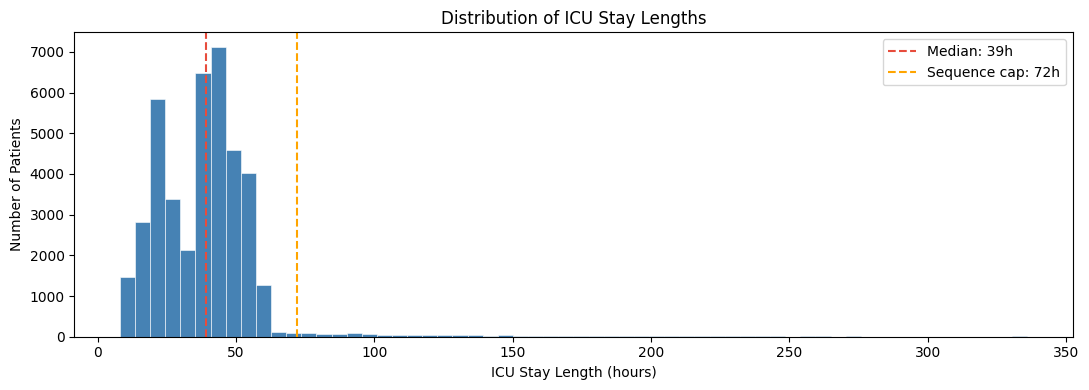

Saved → results/figures/icu_stay_distribution.png


In [8]:
stay_lengths = df.groupby('patient_id')['ICULOS'].max()

pct_under_72 = (stay_lengths <= 72).mean() * 100
print(f"Median ICU stay      : {stay_lengths.median():.0f}h")
print(f"Mean ICU stay        : {stay_lengths.mean():.0f}h")
print(f"Min / Max stay       : {stay_lengths.min()}h / {stay_lengths.max()}h")
print(f"Patients with stay ≤ 72h : {pct_under_72:.1f}%  ← sequences kept in full")
print(f"Patients with stay >  72h : {100-pct_under_72:.1f}%  ← truncated to 72h")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(stay_lengths, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(stay_lengths.median(), color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Median: {stay_lengths.median():.0f}h')
ax.axvline(72, color='orange', linestyle='--', linewidth=1.5,
           label='Sequence cap: 72h')
ax.set_xlabel('ICU Stay Length (hours)')
ax.set_ylabel('Number of Patients')
ax.set_title('Distribution of ICU Stay Lengths')
ax.legend()
plt.tight_layout()
plt.savefig(_root / FIGURES_DIR / 'icu_stay_distribution.png', dpi=150)
plt.show()
print("Saved → results/figures/icu_stay_distribution.png")

### 3c — Time-to-Sepsis Distribution

For sepsis patients: how many hours of ICU data are available before onset? Patients with onset at or before hour 6 are excluded — there is not enough lead time to construct a valid 6-hour early warning label for them.

Sepsis patients total              : 2,932
Onset ≤ 6h (edge cases to exclude) : 706  (24.1%)
Onset >  6h (usable)               : 2,226
Median hours before onset          : 29.0h
Mean hours before onset            : 50.9h


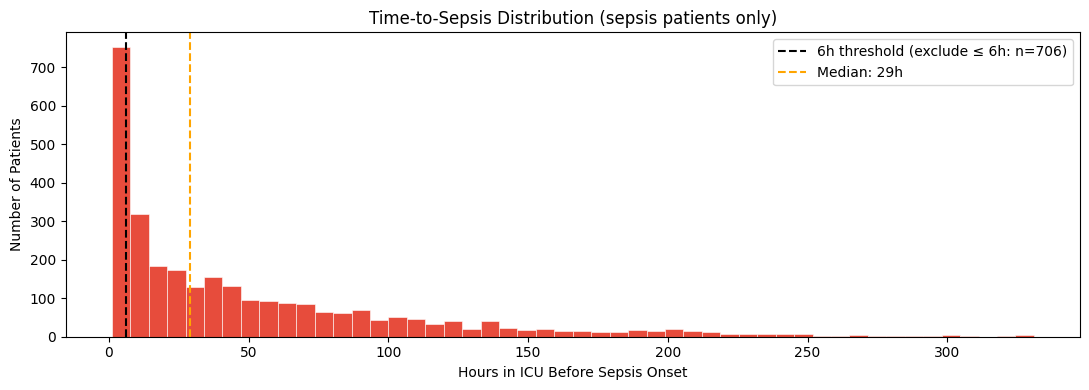

Saved → results/figures/time_to_sepsis.png


In [9]:
df_sepsis   = df[df['patient_id'].isin(sepsis_ids)]
onset_hour  = (df_sepsis[df_sepsis['SepsisLabel'] == 1]
               .groupby('patient_id')['ICULOS'].min())

edge_cases  = (onset_hour <= 6).sum()
print(f"Sepsis patients total              : {len(onset_hour):,}")
print(f"Onset ≤ 6h (edge cases to exclude) : {edge_cases}  ({100*edge_cases/len(onset_hour):.1f}%)")
print(f"Onset >  6h (usable)               : {len(onset_hour)-edge_cases:,}")
print(f"Median hours before onset          : {onset_hour.median():.1f}h")
print(f"Mean hours before onset            : {onset_hour.mean():.1f}h")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(onset_hour, bins=50, color='#e74c3c', edgecolor='white', linewidth=0.4)
ax.axvline(6, color='black', linestyle='--', linewidth=1.5,
           label=f'6h threshold (exclude ≤ 6h: n={edge_cases})')
ax.axvline(onset_hour.median(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: {onset_hour.median():.0f}h')
ax.set_xlabel('Hours in ICU Before Sepsis Onset')
ax.set_ylabel('Number of Patients')
ax.set_title('Time-to-Sepsis Distribution (sepsis patients only)')
ax.legend()
plt.tight_layout()
plt.savefig(_root / FIGURES_DIR / 'time_to_sepsis.png', dpi=150)
plt.show()
print("Saved → results/figures/time_to_sepsis.png")

## 4. Feature Distributions and Outlier Detection

### 4a — Vital Sign Histograms

Examining raw distributions before any clipping or imputation. Physiologically impossible values — HR of 0, temperature of 20°C — appear as extreme spikes and are almost certainly data entry errors that need to be bounded before modelling.

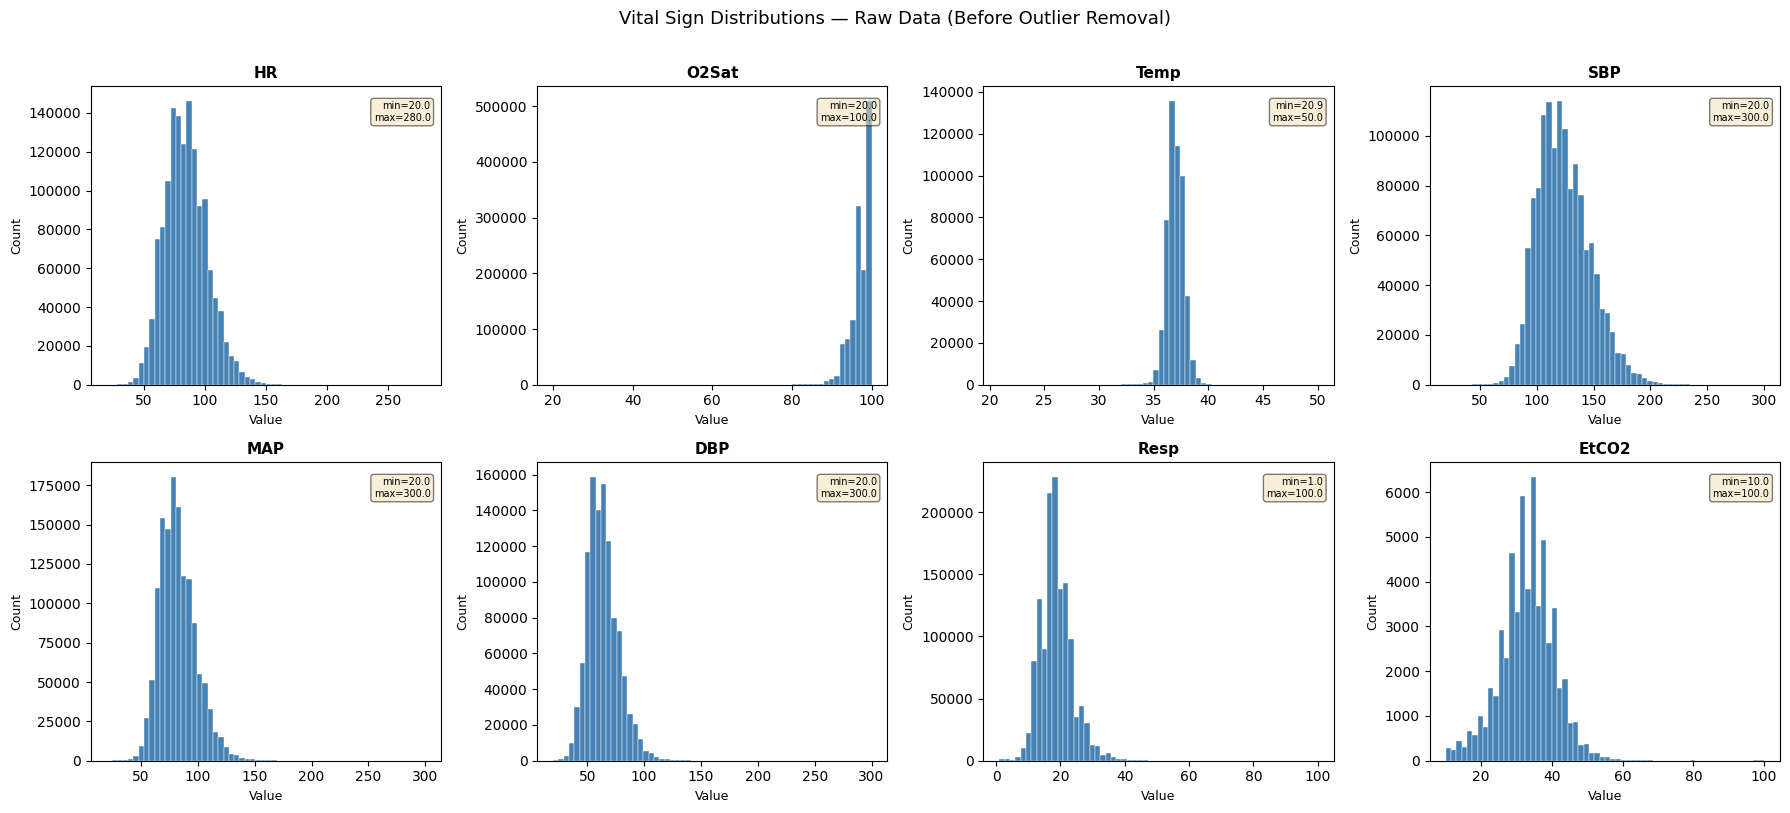

Saved → results/figures/feature_distributions.png


In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flatten(), VITAL_SIGNS):
    col = df[feat].dropna()
    ax.hist(col, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    # Annotate min/max
    ax.text(0.97, 0.95, f'min={col.min():.1f}\nmax={col.max():.1f}',
            transform=ax.transAxes, fontsize=7, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Vital Sign Distributions — Raw Data (Before Outlier Removal)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(_root / FIGURES_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/figures/feature_distributions.png")

### 4b — Extreme Value Summary

Comparing the 1st and 99th percentiles against observed min/max per vital sign to identify the scale of physiologically implausible values.

In [11]:
print(f"{'Feature':<10}  {'min':>7}  {'p1':>7}  {'p99':>7}  {'max':>7}  {'n_obs':>10}")
print("-" * 60)
for feat in VITAL_SIGNS:
    col = df[feat].dropna()
    print(f"{feat:<10}  {col.min():>7.1f}  {col.quantile(0.01):>7.1f}  "
          f"{col.quantile(0.99):>7.1f}  {col.max():>7.1f}  {len(col):>10,}")

Feature         min       p1      p99      max       n_obs
------------------------------------------------------------
HR             20.0     50.0    130.0    280.0   1,398,811
O2Sat          20.0     89.0    100.0    100.0   1,349,474
Temp           20.9     35.1     38.8     50.0     525,226
SBP            20.0     80.0    186.0    300.0   1,325,945
MAP            20.0     52.0    128.0    300.0   1,358,940
DBP            20.0     38.0    103.0    300.0   1,065,656
Resp            1.0      9.0     34.0    100.0   1,313,875
EtCO2          10.0     13.0     52.0    100.0      57,636


### 4c — Outlier Clip Counts

Counting how many values fall outside the defined clinical bounds per feature. These should represent well under 1% of observed values — a higher rate would suggest the bounds need revisiting.

In [12]:
from src.config import OUTLIER_BOUNDS

print(f"{'Feature':<12}  {'Bounds':<14}  {'Clipped':>8}  {'% of obs':>10}  {'Status':>6}")
print("-" * 60)
all_ok = True
for feat, (low, high) in OUTLIER_BOUNDS.items():
    col      = df[feat].dropna()
    n_clip   = int(((df[feat] < low) | (df[feat] > high)).sum())
    pct      = 100 * n_clip / len(col) if len(col) else 0
    status   = 'OK' if pct < 1.0 else 'REVIEW'
    if status == 'REVIEW':
        all_ok = False
    print(f"{feat:<12}  ({low}, {high}){'':>4}  {n_clip:>8,}  {pct:>9.3f}%  {status:>6}")

print()
if all_ok:
    print("All clip rates < 1% — OUTLIER_BOUNDS in config.py are appropriate.")
else:
    print("WARNING: Some features have >1% clip rate — review OUTLIER_BOUNDS.")

Feature       Bounds           Clipped    % of obs  Status
------------------------------------------------------------
HR            (5, 300)             0      0.000%      OK
O2Sat         (50, 100)           272      0.020%      OK
Temp          (25, 45)             6      0.001%      OK
SBP           (40, 300)           114      0.009%      OK
DBP           (20, 200)           103      0.010%      OK
MAP           (30, 250)           458      0.034%      OK
Resp          (4, 60)         1,906      0.145%      OK
Glucose       (20, 1000)            10      0.004%      OK
Lactate       (0.1, 30)             1      0.002%      OK

All clip rates < 1% — OUTLIER_BOUNDS in config.py are appropriate.


## 5. Temporal Trajectories

### 5a — Align Timelines to Hours-Before-Onset

Aligning sepsis patients so hour 0 = onset, and using the final ICU hour as the reference point for non-sepsis patients. Sampling 3,000 non-sepsis patients to balance computation time against representativeness.

In [17]:
def get_aligned_trajectories_fast(df, patient_ids, feature, n_hours_before=24):
    """
    Vectorized trajectory alignment — no per-patient Python loop.
    For each patient, computes hours_before_event (negative = before onset/discharge)
    then pivots into a (n_patients × n_hours_before) matrix.
    """
    cols = ['patient_id', 'ICULOS', 'SepsisLabel', feature]
    sub  = df[df['patient_id'].isin(patient_ids)][cols].copy()

    # Per-patient event hour: onset for sepsis, max ICULOS for non-sepsis
    onset   = (sub[sub['SepsisLabel'] == 1]
               .groupby('patient_id')['ICULOS'].min()
               .rename('event_hour'))
    max_icu = sub.groupby('patient_id')['ICULOS'].max().rename('event_hour')
    event_hour = onset.reindex(sub['patient_id'].unique()).fillna(max_icu)

    sub = sub.merge(event_hour, on='patient_id')
    sub['h_before'] = sub['ICULOS'] - sub['event_hour']   # ≤ 0 before event

    # Keep only the window [-n_hours_before, 0]
    win = sub[(sub['h_before'] >= -n_hours_before) & (sub['h_before'] <= 0)].copy()
    win['t_idx'] = (win['h_before'] + n_hours_before - 1).clip(0, n_hours_before - 1).astype(int)

    pivot = win.pivot_table(index='patient_id', columns='t_idx',
                            values=feature, aggfunc='mean')
    pivot = pivot.reindex(columns=range(n_hours_before))

    # Drop patients with fewer than half the window filled
    pivot = pivot[pivot.notna().sum(axis=1) >= n_hours_before // 2]
    return pivot.values   # shape (n_valid_patients, n_hours_before)

# Sample non-sepsis for balance
np.random.seed(RANDOM_SEED)
non_sep_sample = np.random.choice(list(non_sepsis_ids), size=3000, replace=False)

print(f"Sepsis patients used    : {len(sepsis_ids):,}")
print(f"Non-sepsis patients used: {len(non_sep_sample):,} (sampled)")
print("Ready to compute trajectories.")

Sepsis patients used    : 2,932
Non-sepsis patients used: 3,000 (sampled)
Ready to compute trajectories.


### 5b — Mean Vital Sign Trajectories: Sepsis vs Non-Sepsis

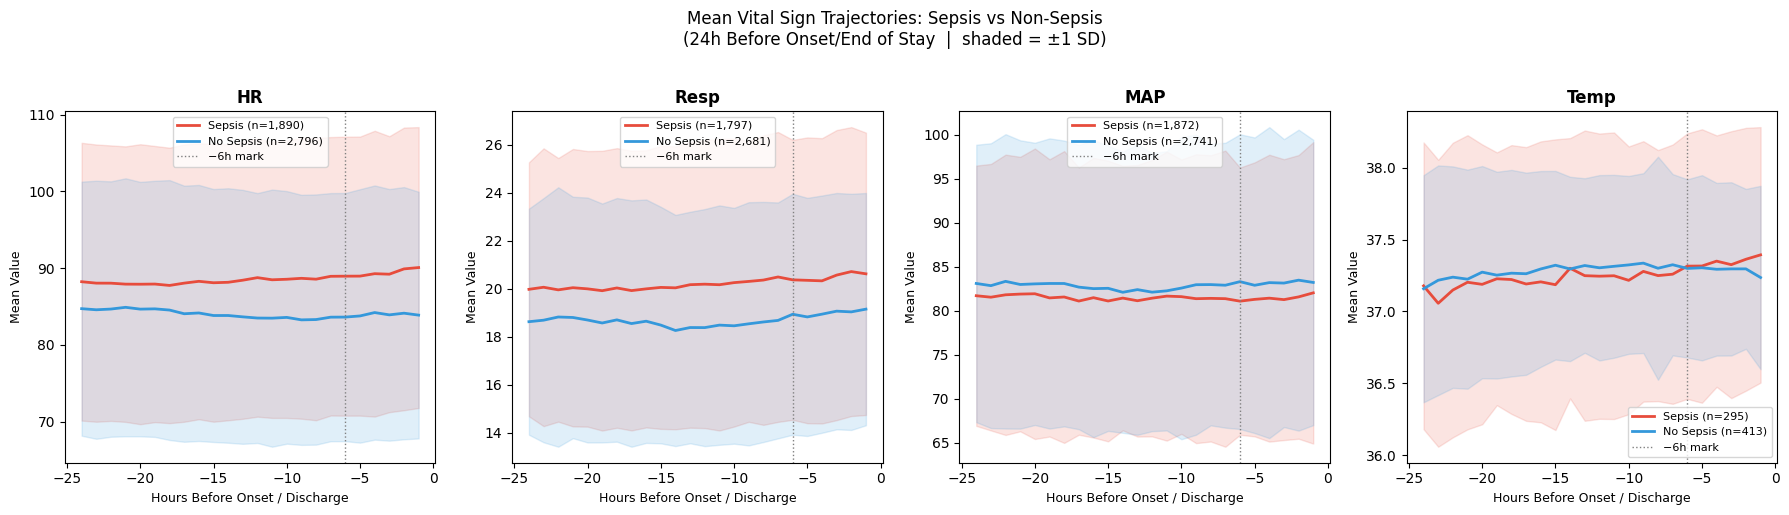

Saved → results/figures/vital_trajectories_sepsis_vs_not.png


In [18]:
features_to_plot = ['HR', 'Resp', 'MAP', 'Temp']
hours = np.arange(-24, 0)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, feat in zip(axes, features_to_plot):
    sep_traj = get_aligned_trajectories_fast(df, list(sepsis_ids),  feat)
    non_traj = get_aligned_trajectories_fast(df, list(non_sep_sample), feat)

    sep_mean = np.nanmean(sep_traj, axis=0)
    sep_std  = np.nanstd(sep_traj,  axis=0)
    non_mean = np.nanmean(non_traj, axis=0)
    non_std  = np.nanstd(non_traj,  axis=0)

    ax.plot(hours, sep_mean, color='#e74c3c', linewidth=2, label=f'Sepsis (n={len(sep_traj):,})')
    ax.plot(hours, non_mean, color='#3498db', linewidth=2, label=f'No Sepsis (n={len(non_traj):,})')
    ax.fill_between(hours, sep_mean - sep_std, sep_mean + sep_std, alpha=0.15, color='#e74c3c')
    ax.fill_between(hours, non_mean - non_std, non_mean + non_std, alpha=0.15, color='#3498db')

    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('Hours Before Onset / Discharge', fontsize=9)
    ax.set_ylabel('Mean Value', fontsize=9)
    ax.axvline(-6, color='grey', linestyle=':', linewidth=1, label='−6h mark')
    ax.legend(fontsize=8)

plt.suptitle('Mean Vital Sign Trajectories: Sepsis vs Non-Sepsis\n'
             '(24h Before Onset/End of Stay  |  shaded = ±1 SD)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(_root / FIGURES_DIR / 'vital_trajectories_sepsis_vs_not.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/figures/vital_trajectories_sepsis_vs_not.png")

### 5c — Trajectory Analysis: Findings

**Vital sign trajectories diverge measurably in the 24 hours before sepsis onset.**

Heart rate (HR) is the clearest signal: sepsis patients average ~90 bpm at onset vs ~84 bpm for non-sepsis patients — a +6.4 bpm gap sustained across the full 24-hour window. Respiratory rate shows a similar but smaller elevation (+1.5 breaths/min). MAP shows a modest difference (−0.7 mmHg), suggesting haemodynamic compromise is mild on average at this label definition, though individual patients show larger drops. Temperature shows minimal separation (+0.06°C), consistent with the known variability of fever in early sepsis.

These diverging trajectories represent the temporal signal an LSTM is designed to exploit. XGBoost operates on a single snapshot row — it can learn that elevated HR is predictive, but not that HR has been rising for 12 hours. If the LSTM outperforms XGBoost in the 2×2 experiment, this sustained HR and Resp divergence is the likely mechanistic explanation.

## 6. Feature Correlation Analysis

### 6a — Correlation Matrix

Checking for highly correlated feature pairs. Correlation does not hurt XGBoost's predictive performance, but it does affect SHAP interpretability — importance gets distributed across correlated pairs, which needs to be accounted for when reading the feature attribution plots.

In [ ]:
corr_matrix = df[ALL_FEATURES].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    corr_matrix, cmap='coolwarm', center=0,
    annot=False, square=True, linewidths=0.3,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8},
    ax=ax
)
ax.set_title('Feature Correlation Matrix (all 40 features)', fontsize=13)
plt.tight_layout()
plt.savefig(_root / FIGURES_DIR / 'feature_correlation_matrix.png', dpi=150)
plt.show()
print("Saved → results/figures/feature_correlation_matrix.png")

### 6b — Correlated Pairs (|r| > 0.70)

In [ ]:
THRESHOLD = 0.70
pairs = []
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > THRESHOLD:
            pairs.append({'feature_1': cols[i], 'feature_2': cols[j], 'r': round(r, 3)})

high_corr_df = (pd.DataFrame(pairs)
                  .sort_values('r', key=abs, ascending=False)
                  .reset_index(drop=True))

print(f"Pairs with |r| > {THRESHOLD}:")
print(high_corr_df.to_string(index=False))

high_corr_df.to_csv(_root / METRICS_DIR / 'high_correlation_pairs.csv', index=False)
print(f"\nSaved → results/metrics/high_correlation_pairs.csv")

### 6c — Handling Correlated Features

**No features are dropped based on correlation alone.**

The correlated pairs identified are:

| Pair | r | Clinical Reason |
|---|---|---|
| Unit1 / Unit2 | −1.00 | Binary flags — always sum to 1 (ICU type A or B) |
| Bilirubin_direct / Bilirubin_total | +0.96 | Direct is a component of total bilirubin |
| Hct / Hgb | +0.95 | Haematocrit and haemoglobin both measure red cell mass |
| BaseExcess / HCO3 | +0.86 | Both derived from the same blood gas equation |
| MAP / DBP | +0.85 | MAP ≈ DBP + ⅓(SBP − DBP) by formula |
| SBP / MAP | +0.78 | MAP is computed from SBP and DBP |

Removing features on correlation alone is not justified — each may carry independent predictive signal, and tree-based models like XGBoost are robust to multicollinearity. When interpreting SHAP plots, near-zero importance for one of a correlated pair should be read as a redundancy artefact rather than a genuine signal of unimportance.